# Aircraft Engine Predictive Maintenance

## Notebook 4: Machine Learning Models

### Objectives

- Load processed dataset
- Split data
- Train ML models
- Compare performance
- Save best model

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
data = pd.read_csv("../dataset/processed_train.csv")

data.head()

,engine_id,cycle,setting1,setting2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,0.0,0.00000,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191.0
1,0.0,0.00277,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190.0
2,0.0,0.00554,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189.0
3,0.0,0.00831,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188.0
4,0.0,0.01108,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187.0


In [3]:
X = data.drop("RUL", axis=1)

y = data["RUL"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (20631, 19)
Target Shape : (20631,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (16504, 19)
Testing Samples : (4127, 19)


In [5]:
def evaluate_model(model, X_test, y_test):

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    r2 = r2_score(y_test, prediction)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return mae, rmse, r2

In [6]:
lr = LinearRegression()

lr.fit(X_train, y_train)

print("Linear Regression Results")

lr_mae, lr_rmse, lr_r2 = evaluate_model(
    lr,
    X_test,
    y_test
)

Linear Regression Results
MAE  : 30.42
RMSE : 39.23
R²   : 0.6632


In [7]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

print("Decision Tree Results")

dt_mae, dt_rmse, dt_r2 = evaluate_model(
    dt,
    X_test,
    y_test
)

Decision Tree Results
MAE  : 13.37
RMSE : 24.58
R²   : 0.8677


In [8]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

print("Random Forest Results")

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    rf,
    X_test,
    y_test
)

Random Forest Results
MAE  : 11.03
RMSE : 16.29
R²   : 0.9419


In [9]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,30.415293,39.228015,0.663185
1,Decision Tree,13.370487,24.584051,0.867717
2,Random Forest,11.033275,16.292920,0.941897


In [10]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,11.033275,16.292920,0.941897
1,Decision Tree,13.370487,24.584051,0.867717
0,Linear Regression,30.415293,39.228015,0.663185


In [11]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,cycle,0.539743
0,engine_id,0.171076
11,sensor_11,0.133616
10,sensor_9,0.031961
6,sensor_4,0.028152
12,sensor_12,0.019742
14,sensor_14,0.017293
8,sensor_7,0.009733
13,sensor_13,0.007566
15,sensor_15,0.006796


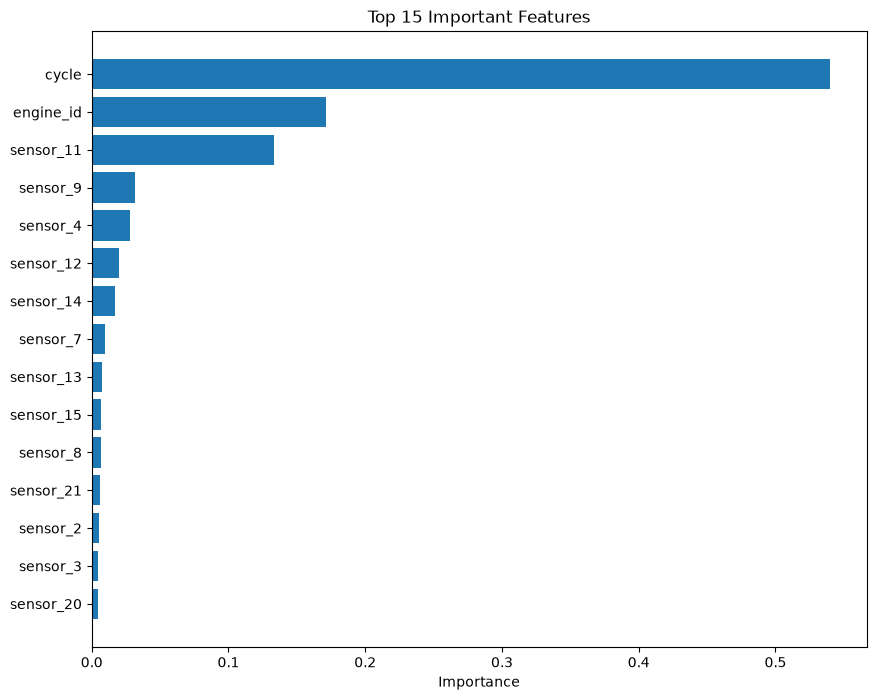

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:15],

    importance["Importance"][:15]

)

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [13]:
joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

print("Random Forest Model Saved Successfully")

Random Forest Model Saved Successfully


In [14]:
loaded_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [15]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Remaining Useful Life")

print(prediction)

Predicted Remaining Useful Life
[129.865]
